# Homework 2
### Grupo 127
#### André Melo (ist1106937) e Gonçalo Aleixo (ist1106900)

## II. Programming and critical analysis [7v]
**Consider the heart-disease.csv dataset available at the course webpage’s homework tab.**
**Using sklearn, apply a 5-fold stratified cross-validation with shuffling (random_state=0) for the**
**assessment of predictive models along this section.**

**1) Compare the performance of a 𝑘𝑁𝑁 with 𝑘 = 5 and a naïve Bayes with Gaussian**
**assumption (consider all remaining parameters as default):**

**a. [1.0v] Plot two boxplots with the fold accuracies for each classifier. Is there one**
**more stable than the other regarding performance? Why do you think that is the**
**case? Explain.**

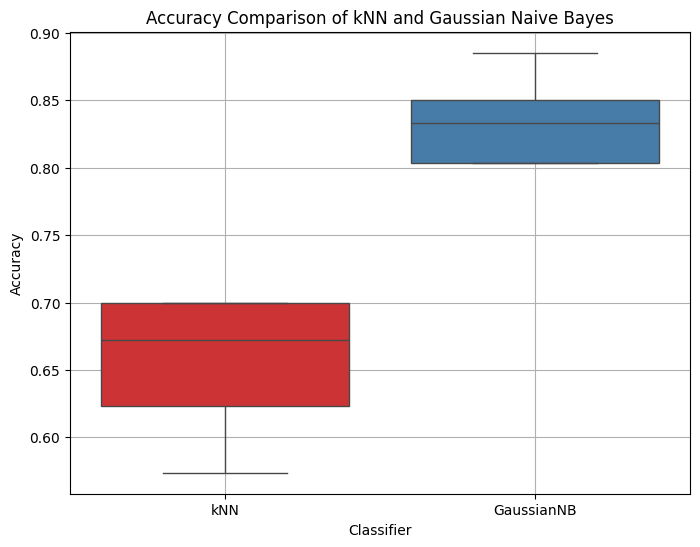

In [18]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Loading the CSV file
df = pd.read_csv('heart-disease.csv')

#Separate features(X) from the target(Y)
X = df.drop(columns=['target'])
y = df['target']

#kNN
neighbor = KNeighborsClassifier(n_neighbors=5)

# Bayesian
gnb = GaussianNB()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Cross-validation for kNN
knn_scores = cross_val_score(neighbor, X, y, cv=cv)

# Cross-validation for Gaussian Naive Bayes
gnb_scores = cross_val_score(gnb, X, y, cv=cv)

# Boxplot 
data = pd.DataFrame({
    'Classifier': ['kNN'] * len(knn_scores) + ['GaussianNB'] * len(gnb_scores),
    'Accuracy': list(knn_scores) + list(gnb_scores)
})

plt.figure(figsize=(8, 6))
sns.boxplot(x='Classifier', y='Accuracy', hue='Classifier', data=data, palette='Set1', dodge=False, legend=False)
plt.title('Accuracy Comparison of kNN and Gaussian Naive Bayes')
plt.grid(True)
plt.show()

Gaussian Naive Bayes aparenta ser mais estável em comparação com o kNN em termos de desempenho. O boxplot do Gaussian Naive Bayes apresenta um intervalo interquartil menor e whiskers mais curtos, o que indica que os seus valores de exatidão ao longo das diferentes iterações são mais próximos entre si, com menos flutuações entre os valores máximos e mínimos. Isto sugere que o Gaussian Naive Bayes tem um desempenho mais consistente, independentemente da forma como os dados são divididos durante a validação cruzada.

O Gaussian Naive Bayes é um modelo probabilístico que faz suposições fortes, como a independência entre as características e a distribuição Gaussiana dos dados. Essas suposições simplificam o processo de aprendizagem e tornam o modelo menos sensível a variações nos dados de treino, resultando num desempenho mais consistente ao longo das diferentes iterações.

Por outro lado, o kNN é um algoritmo baseado em distâncias que depende fortemente da distribuição específica dos pontos de dados no conjunto de treino. Pequenas alterações na composição dos dados de treino, como quais pontos são incluídos ou excluídos numa determinada iteração, podem ter um impacto significativo nas suas previsões. Como resultado, o kNN tende a exibir mais variabilidade no seu desempenho em diferentes divisões de dados, tornando-o menos estável do que o Gaussian Naive Bayes neste contexto.

Em suma, o Gaussian Naive Bayes é mais estável devido à sua dependência de suposições probabilísticas, enquanto a sensibilidade do kNN à estrutura local dos dados leva a uma maior variabilidade no desempenho.

**b. [1.0v] Report the accuracy of both models, this time scaling the data with a**
**Min-Max scaler before training the models. Explain the impact that this**
**preprocessing step has on the performance of each model, providing an**
**explanation for the results.**

In [31]:
#As variáveis X, neighbor e gnb vêm do excerto de código da alínea a
from sklearn.preprocessing import MinMaxScaler

#Apply MinMaxScaler to the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

#Cross-validation for kNN with scaled data
knn_scaled_scores = cross_val_score(neighbor, X_scaled, y, cv=cv)

#Cross-validation for Gaussian Naive Bayes with scaled data
gnb_scaled_scores = cross_val_score(gnb, X_scaled, y, cv=cv)

#Calculate the mean accuracy for both models
knn_scaled_mean_accuracy = knn_scaled_scores.mean()
gnb_scaled_mean_accuracy = gnb_scaled_scores.mean()

#Output
print(f"Accuracy for kNN (k=5) with MinMax scaling: {knn_scaled_mean_accuracy:.4f}")
print(f"Accuracy for Gaussian Naive Bayes with MinMax scaling: {gnb_scaled_mean_accuracy:.4f}")

Accuracy for kNN (k=5) with MinMax scaling: 0.8217
Accuracy for Gaussian Naive Bayes with MinMax scaling: 0.8350


No caso do kNN, a melhoria na exatidão foi mais significativa. Como o kNN é um algoritmo baseado em distâncias, ele depende fortemente da escala das características para calcular as distâncias entre os pontos de dados. Sem a normalização, as características com intervalos numéricos maiores podem dominar os cálculos de distância, levando a previsões enviesadas. Ao aplicar a normalização Min-Max, todas as características são normalizadas para o mesmo intervalo, o que garante que cada característica contribua de forma equitativa para os cálculos de distância. Isto resultou numa avaliação mais equilibrada dos pontos de dados e, consequentemente, numa melhoria do desempenho do modelo kNN.

Por outro lado, o Gaussian Naive Bayes foi menos afetado pelo processo de normalização. Este algoritmo funciona calculando a probabilidade de cada característica para cada classe, assumindo uma distribuição normal (Gaussiana). Como o GNB calcula estas probabilidades de forma independente para cada característica, é geralmente menos sensível à escala absoluta das mesmas. No entanto, a normalização Min-Max trouxe uma ligeira melhoria no desempenho ao tornar as distribuições das características mais uniformes, especialmente no que diz respeito à variância. Embora o efeito não tenha sido tão pronunciado como no kNN, a normalização ajudou a refinar as estimativas de probabilidade para cada classe, levando a um pequeno aumento na exatidão.

Em suma, a normalização Min-Max teve um impacto maior no kNN devido à sua dependência dos cálculos de distância, enquanto o Gaussian Naive Bayes, sendo um modelo probabilístico, apenas registou uma ligeira melhoria resultante da distribuição mais uniforme das características.

**c. [1.0v] Using scipy, test the hypothesis “the 𝑘𝑁𝑁 model is statistically superior to**
**naïve Bayes regarding accuracy”, asserting whether it is true.**

H0: Exatidão (Accuracy) do kNN é igual à accuracy do GNB
H1: Exatidão (Accuracy) do kNN é maior do que a accuracy do GNB

In [33]:
from scipy import stats

res = stats.ttest_rel(knn_scores, gnb_scores, alternative='greater')
print("p-value=",res.pvalue)

p-value= 0.9987020187220139


Devido ao valor do p-value, não podemos rejeitar a hipótese nula(H0) para níveis de significância de 1%, 5%, 10%

Concluímos assim que não há uma diferença estatisticamente significante entre os modelos kNN e naive Bayes e não podemos afirmar com confiança que kNN é estatisticamente superior ao naive Bayes em termos de accuracy.

**2) Using a 80-20 train-test split, vary the number of neighbors of a 𝑘𝑁𝑁 classifier using**
**𝑘 = {1, 5, 10, 20, 30}. Additionally, for each 𝑘, train one classifier using uniform weights**
**and distance weights.**

**a. [1.0v] Plot the train and test accuracy for each model.**

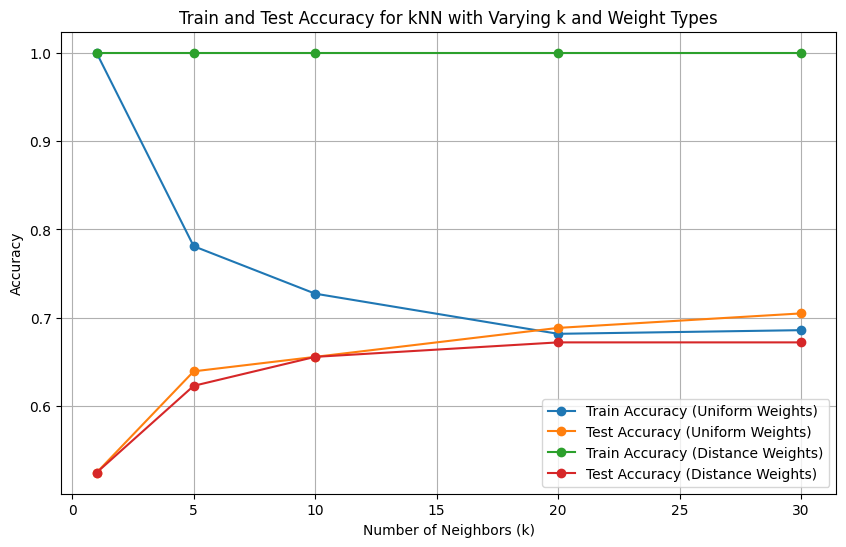

In [68]:
from sklearn.metrics import accuracy_score

#80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#Lists to store results
train_accuracy_uniform = []
test_accuracy_uniform = []
train_accuracy_distance = []
test_accuracy_distance = []

k_values = [1, 5, 10, 20, 30]

for k in k_values:
    #Initialize 
    knn_uniform = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    knn_distance = KNeighborsClassifier(n_neighbors=k, weights='distance')
    
    #Train the classifiers
    knn_uniform.fit(X_train, y_train)
    knn_distance.fit(X_train, y_train)
    
    #Predict on the train and test set for uniform weights
    train_pred_uniform = knn_uniform.predict(X_train)
    test_pred_uniform = knn_uniform.predict(X_test)
    
    #Predict on the train and test set for distance weights
    train_pred_distance = knn_distance.predict(X_train)
    test_pred_distance = knn_distance.predict(X_test)

    #Calculate and store accuracies
    train_accuracy_uniform.append(accuracy_score(y_train, train_pred_uniform))
    test_accuracy_uniform.append(accuracy_score(y_test, test_pred_uniform))
    train_accuracy_distance.append(accuracy_score(y_train, train_pred_distance))
    test_accuracy_distance.append(accuracy_score(y_test, test_pred_distance))

#Plot 
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracy_uniform, label='Train Accuracy (Uniform Weights)', marker='o')
plt.plot(k_values, test_accuracy_uniform, label='Test Accuracy (Uniform Weights)', marker='o')
plt.plot(k_values, train_accuracy_distance, label='Train Accuracy (Distance Weights)', marker='o')
plt.plot(k_values, test_accuracy_distance, label='Test Accuracy (Distance Weights)', marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('Train and Test Accuracy for kNN with Varying k and Weight Types')
plt.legend()
plt.grid(True)
plt.show()

**b. [1.5v] Explain the impact of increasing the neighbors on the generalization ability of the models.**

Quando o número de vizinhos (𝑘) é pequeno, como 𝑘 = 1, o modelo torna-se muito sensível aos dados de treino, focando-se em pontos específicos. Isto leva a overfitting, ou seja, o modelo ajusta-se demasiado bem ao treino, mas tem dificuldade em generalizar para novos dados.

À medida que o 𝑘 aumenta, por exemplo para 𝑘 = 5 ou 10, o modelo torna-se mais robusto, suavizando as fronteiras de decisão. Considerar mais vizinhos reduz o impacto de outliers, permitindo ao modelo generalizar melhor. Aqui, o modelo atinge um equilíbrio entre viés e variância, resultando num desempenho superior no conjunto de teste.

No entanto, ao continuar a aumentar o número de vizinhos, como em 𝑘 = 20 ou 𝑘 = 30, o modelo começa a underfitting, tornando-se demasiado simples. Com muitos vizinhos, as previsões são baseadas numa média muito ampla, o que torna o modelo menos capaz de capturar padrões importantes, prejudicando tanto o treino como o teste.

**3) [1.5v] Considering the unique properties of the heart-disease.csv dataset, identify two**
**possible difficulties of the naïve Bayes model used in the previous exercises when learning**
**from the given dataset.**

- **Suposição de independência entre as variáveis:** O Naïve Bayes assume que todas as variáveis são independentes entre si, o que muitas vezes não é realista em datasets do mundo real. No conjunto de dados de doenças cardíacas, é provável que muitas variáveis estejam correlacionadas. Por exemplo, variáveis como os níveis de colesterol (chol) e a pressão arterial (trestbps) podem estar relacionadas entre si no diagnóstico de doenças cardíacas, violando a suposição de independência. Deste modo, ao ignorar relações entre parâmetros, o modelo pode produzir previsões imprecisas, diminuindo o seu desempenho.

- **Tratamento de variáveis contínuas:** O Naïve Bayes com a suposição Gaussiana, que é frequentemente usado para variáveis contínuas, assume que os dados de cada variável seguem uma distribuição normal (Gaussiana). No entanto, algumas variáveis contínuas no conjunto de dados, como a idade, colesterol (chol) ou oldpeak (uma medida da depressão do segmento ST), podem não seguir uma distribuição normal. Se a distribuição real se desviar significativamente da suposição Gaussiana, o modelo pode ter dificuldades em estimar corretamente as probabilidades, o que pode levar a previsões subótimas.